In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn import metrics

from zipfile import ZipFile
import cv2
import gc
import os

import warnings
warnings.filterwarnings('ignore')

In [3]:
path = 'lung-and-colon-cancer-histopathological-images'
os.listdir(path)

['lung_colon_image_set']

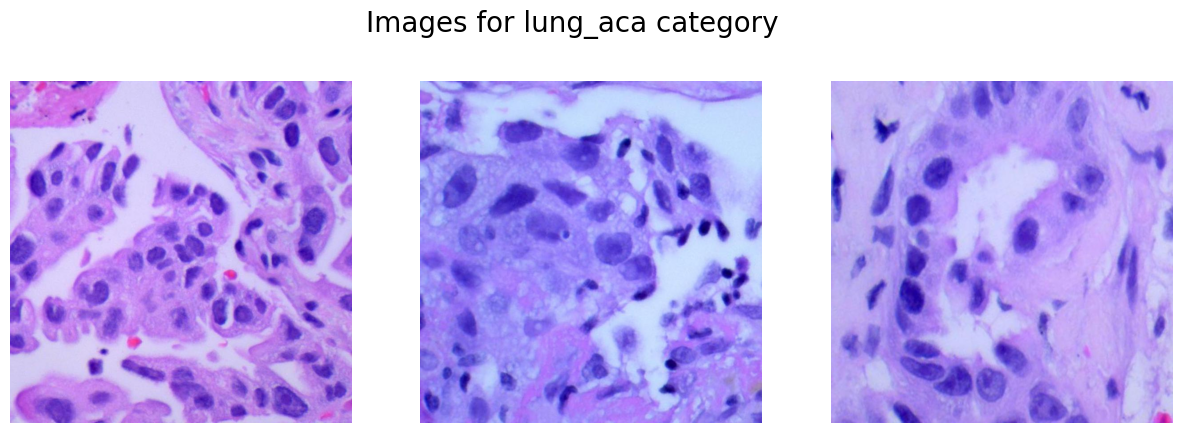

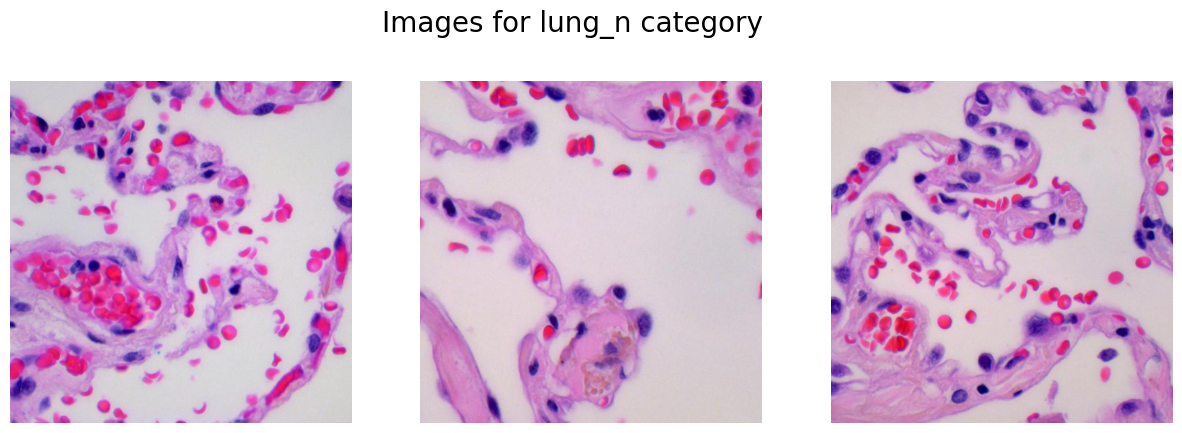

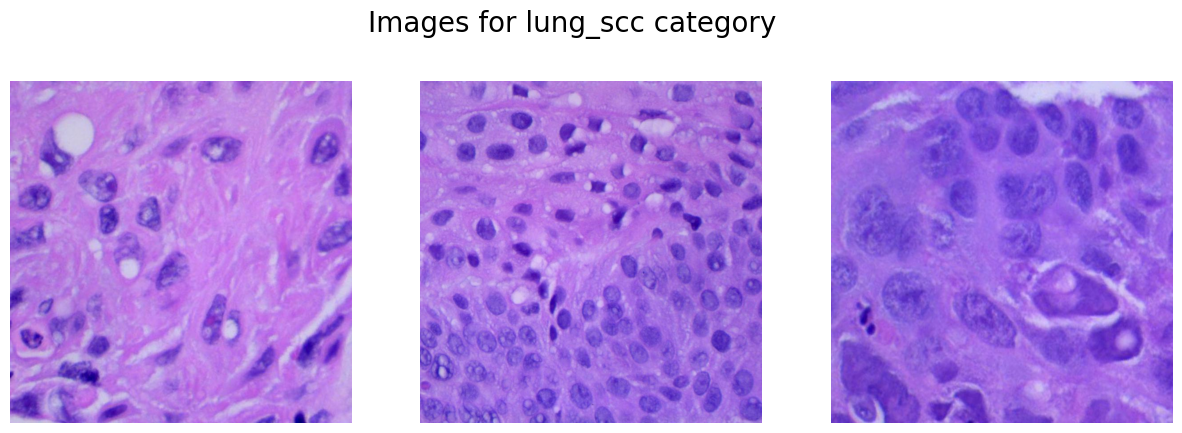

In [4]:
path = 'lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets'

classes = ['lung_aca', 'lung_n', 'lung_scc']

for cat in classes:
    image_dir = f'{path}/{cat}'
    images = os.listdir(image_dir)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Images for {cat} category', fontsize=20)

    for i in range(3):
        k = np.random.randint(0, len(images))
        img = np.array(Image.open(f'{path}/{cat}/{images[k]}'))
        ax[i].imshow(img)
        ax[i].axis('off')

    plt.show()

In [5]:
!pip install -q transformers torch torchvision

In [6]:
import torch
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=3,
    ignore_mismatched_sizes=True
)

print("ViT Loaded Successfully")

You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT Loaded Successfully


In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root='lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets',
    transform=transform
)

# 80 / 20 split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Classes:", dataset.classes)

Training Images: 12000
Validation Images: 3000
Classes: ['lung_aca', 'lung_n', 'lung_scc']


In [8]:
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

In [9]:
model.train()

running_loss = 0

for batch_idx, (images, labels) in enumerate(train_loader):

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(pixel_values=images).logits
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    if batch_idx % 50 == 0:
        print(f"Batch {batch_idx}, Loss: {loss.item():.4f}")

print("Epoch Completed")
print("Average Loss:", running_loss / len(train_loader))

Batch 0, Loss: 1.0763
Batch 50, Loss: 0.0699
Batch 100, Loss: 0.0813
Batch 150, Loss: 0.1497
Batch 200, Loss: 0.0845
Batch 250, Loss: 0.0128
Batch 300, Loss: 0.0023
Batch 350, Loss: 0.0601
Batch 400, Loss: 0.0167
Batch 450, Loss: 0.2608
Batch 500, Loss: 0.0191
Batch 550, Loss: 0.0199
Batch 600, Loss: 0.0093
Batch 650, Loss: 0.4214
Batch 700, Loss: 0.0082
Batch 750, Loss: 0.0075
Batch 800, Loss: 0.0969
Batch 850, Loss: 0.0021
Batch 900, Loss: 0.2716
Batch 950, Loss: 0.0066
Batch 1000, Loss: 0.0005
Batch 1050, Loss: 0.0016
Batch 1100, Loss: 0.0009
Batch 1150, Loss: 0.0041
Batch 1200, Loss: 0.0032
Batch 1250, Loss: 0.0004
Batch 1300, Loss: 0.0051
Batch 1350, Loss: 0.0021
Batch 1400, Loss: 0.1527
Batch 1450, Loss: 0.0028
Epoch Completed
Average Loss: 0.05969676121822946


In [10]:
torch.save(model.state_dict(), "vit_lung_model_80_20.pth")
print("Model saved successfully")

Model saved successfully


In [11]:
import torch
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=3,
    ignore_mismatched_sizes=True
)

model.load_state_dict(torch.load("vit_lung_model_80_20.pth", map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully")

You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded successfully


In [12]:
# Validation Evaluation + Detailed Metrics

import torch
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

running_loss = 0

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(val_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=images).logits

        # Loss
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        # Prediction
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if batch_idx % 50 == 0:
            print(f"Validated Batch {batch_idx}")

# Final Accuracy
accuracy = 100 * correct / total
avg_loss = running_loss / len(val_loader)

print("\nValidation Completed")
print("Validation Accuracy:", accuracy, "%")
print("Validation Loss:", avg_loss)

# Class Names
class_names = dataset.classes

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Validated Batch 0
Validated Batch 50
Validated Batch 100
Validated Batch 150
Validated Batch 200
Validated Batch 250
Validated Batch 300
Validated Batch 350

Validation Completed
Validation Accuracy: 99.46666666666667 %
Validation Loss: 0.014853287682829735

Classification Report:
              precision    recall  f1-score   support

    lung_aca       1.00      0.99      0.99       990
      lung_n       1.00      1.00      1.00       959
    lung_scc       0.99      1.00      0.99      1051

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000


Confusion Matrix:
[[ 976    4   10]
 [   0  959    0]
 [   2    0 1049]]


In [13]:
report = classification_report(all_labels, all_preds, target_names=class_names)
cm = confusion_matrix(all_labels, all_preds)

with open("validation_results.txt", "w") as f:
    f.write(f"Validation Accuracy: {accuracy:.4f}%\n")
    f.write(f"Validation Loss: {avg_loss:.6f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)
    f.write("\n\nConfusion Matrix:\n")
    f.write(str(cm))

print("Validation results saved successfully")

Validation results saved successfully


In [20]:
# Predict Single Image (Next Step Before GUI)

import torch
from PIL import Image
from torchvision import transforms

# Class names
class_names = ['lung_aca', 'lung_n', 'lung_scc']

# Image transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Enter image path here
img_path = "lung-and-colon-cancer-histopathological-images/Test3.jpeg"   # change this

# Load image
image = Image.open(img_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(device)

# Prediction
model.eval()

with torch.no_grad():
    outputs = model(pixel_values=image_tensor).logits
    probabilities = torch.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

predicted_class = class_names[predicted.item()]
confidence_score = confidence.item() * 100

print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence_score, 2), "%")

Predicted Class: lung_scc
Confidence: 99.86 %
